In [1]:
import pandas as pd
import numpy as np
import itertools as it
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%matplotlib inline
sns.set_theme(style="darkgrid")
colors=sns.color_palette("hls", 50)
color4=sns.color_palette("hls", 4)
sns.set(rc={'figure.figsize':(50,40)})

In [3]:
%store -r pltCellColors ordStemCells

In [4]:
rep="/Users/gilles/sDrive/Recherche/BoSchal/WordStructure/Data/vlexique2/"
rep="/Users/gilles/Downloads/vlexique2/"

In [5]:
dfVlexique=pd.read_csv(rep+"vlexique_paradigms.csv")

In [6]:
dfVlexique.drop("frequency_per_million",axis=1,inplace=True)
dfVlexique.loc[:,"phon_form"]=dfVlexique.loc[:,"phon_form"].apply(lambda x: x.replace(" ",""))
dfVlexique.orth_form=dfVlexique.orth_form.astype(str)
dfVlexique.head()

,form_id,lexeme,cell,phon_form,orth_form,overabundance_tag,frequency
0,form-abaisser-cond-1pl,abaisser,cond.prs.1.pl,abɛsəʁjɔ̃,abaisserions,NaN,0
1,form-abaisser-cond-1sg,abaisser,cond.prs.1.sg,abɛsəʁE,abaisserais,NaN,38
2,form-abaisser-cond-2pl,abaisser,cond.prs.2.pl,abɛsəʁje,abaisseriez,NaN,9
3,form-abaisser-cond-2sg,abaisser,cond.prs.2.sg,abɛsəʁE,abaisserais,NaN,14
4,form-abaisser-cond-3pl,abaisser,cond.prs.3.pl,abɛsəʁE,abaisseraient,NaN,4


In [7]:
maxFreq=dfVlexique.frequency.max()

### Correspondances entre Flexique et Grace

In [8]:
cells=dfVlexique.cell.unique().tolist()
caseGrace={}
caseFlex={}
for cell in cells:
    lFeat=cell.split(".")
    nFeat=len(lFeat)
    if nFeat==1:
        caseGrace[cell]=cell
    elif nFeat==2:
        caseGrace[cell]="pP"
    elif lFeat[1]=="prs":
        if lFeat[0]=="imp":
            caseGrace[cell]="pI"+lFeat[2]+lFeat[3][0].upper()
        else:
            caseGrace[cell]="p"+lFeat[0][0]+lFeat[2]+lFeat[3][0].upper()
    elif lFeat[1]=="pst":
        if lFeat[0]=="ind":
            caseGrace[cell]="ai"+lFeat[2]+lFeat[3][0].upper()
        elif lFeat[0]=="sbjv":
            caseGrace[cell]="is"+lFeat[2]+lFeat[3][0].upper()
        else:
            caseGrace[cell]="pp"+lFeat[2].upper()+lFeat[3][0].upper()
    else:
        caseGrace[cell]=lFeat[1][0]+lFeat[0][0]+lFeat[2]+lFeat[3][0].upper()
for case in caseGrace:
    caseFlex[caseGrace[case]]=case

In [9]:
pltFlexColors={}
for case in pltCellColors:
    pltFlexColors[caseFlex[case]]=pltCellColors[case]

In [10]:
dfVlexique=dfVlexique.groupby(["lexeme","cell","phon_form"])[["orth_form","frequency"]].agg({"orth_form":', '.join,"frequency":"sum"}).reset_index()

In [11]:
dfVlexique[dfVlexique.orth_form.str.contains(",")]

,lexeme,cell,phon_form,orth_form,frequency
1072,abréger,cond.prs.1.pl,abʁɛʒəʁjɔ̃,"abrègerions, abrégerions",0
1073,abréger,cond.prs.1.sg,abʁɛʒəʁE,"abrègerais, abrégerais",2
1074,abréger,cond.prs.2.pl,abʁɛʒəʁje,"abrègeriez, abrégeriez",0
1075,abréger,cond.prs.2.sg,abʁɛʒəʁE,"abrègerais, abrégerais",0
1076,abréger,cond.prs.3.pl,abʁɛʒəʁE,"abrègeraient, abrégeraient",1
...,...,...,...,...,...
269451,éviscérer,ind.fut.1.sg,EvisɛʁəʁE,"éviscèrerai, éviscérerai",3
269452,éviscérer,ind.fut.2.pl,Evisɛʁəʁe,"éviscèrerez, éviscérerez",0
269453,éviscérer,ind.fut.2.sg,Evisɛʁəʁa,"éviscèreras, éviscéreras",1
269454,éviscérer,ind.fut.3.pl,Evisɛʁəʁɔ̃,"éviscèreront, éviscéreront",0


In [12]:
def ExtractSubLex(df,low,high=maxFreq):
    return df[(low<df.frequency)&(df.frequency<=high)].sort_values("frequency")

In [13]:
def MakeParadigm(df):
    return pd.pivot_table(df, values='phon_form', index=['lexeme'], columns=['cell'], aggfunc=lambda x: ",".join(x))

In [14]:
def pivotLexique(lexique):
    paradigmes=pd.pivot_table(lexique, values='phon_form', index=['lexeme'], columns=['cell'], aggfunc=lambda x: ",".join(x))
    return paradigmes

In [15]:
%store -r pltCellColors
def colorerXTicks(gAX,fSize=12):
    xlabels=gAX.get_xticklabels()
    for xlabel in xlabels:
        xtext=xlabel.get_text()
        xlabel.set_backgroundcolor(pltFlexColors[xtext])
        xlabel.set_family("monospace")
        
def colorerYTicks(gAX,fSize=12):
    ylabels=gAX.get_yticklabels()
    for ylabel in ylabels:
        ytext=ylabel.get_text()
        ylabel.set_backgroundcolor(pltFlexColors[ytext])
        ylabel.set_family("monospace")

In [16]:
def GetCoforms(dfSource):
    cols=dfSource.columns.tolist()[1:]
    coforms={}
    for (c1,c2) in it.combinations_with_replacement(cols,2):
        if c1 not in coforms: coforms[c1]={}
        coforms[c1][c2]=dfSource[[c1,c2]].dropna().count().iloc[0]
        if c2 not in coforms: coforms[c2]={}
        coforms[c2][c1]=dfSource[[c1,c2]].dropna().count().iloc[0]
    return coforms

In [17]:
dfTot=MakeParadigm(dfVlexique)
coforms=GetCoforms(dfTot)
dfCoforms=pd.DataFrame(coforms)
# dfCoforms

In [18]:
parCols=dfCoforms.index.tolist()
reCols=[hc for hc in parCols if hc in dfCoforms.columns]

In [19]:
ordStem=sorted(reCols, key = lambda x: ordStemCells.index(caseGrace[x]))
ordStem

['ind.prs.1.sg',
 'ind.prs.2.sg',
 'ind.prs.3.sg',
 'ind.prs.1.pl',
 'ind.prs.2.pl',
 'ind.prs.3.pl',
 'ind.ipfv.1.sg',
 'ind.ipfv.2.sg',
 'ind.ipfv.3.sg',
 'ind.ipfv.1.pl',
 'ind.ipfv.2.pl',
 'ind.ipfv.3.pl',
 'ind.fut.1.sg',
 'ind.fut.2.sg',
 'ind.fut.3.sg',
 'ind.fut.1.pl',
 'ind.fut.2.pl',
 'ind.fut.3.pl',
 'cond.prs.1.sg',
 'cond.prs.2.sg',
 'cond.prs.3.sg',
 'cond.prs.2.pl',
 'cond.prs.3.pl',
 'sbjv.prs.1.sg',
 'sbjv.prs.2.sg',
 'sbjv.prs.3.sg',
 'sbjv.prs.1.pl',
 'sbjv.prs.2.pl',
 'sbjv.prs.3.pl',
 'ind.pst.1.sg',
 'ind.pst.2.sg',
 'ind.pst.3.sg',
 'ind.pst.1.pl',
 'ind.pst.2.pl',
 'ind.pst.3.pl',
 'sbjv.pst.1.sg',
 'sbjv.pst.2.sg',
 'sbjv.pst.3.sg',
 'sbjv.pst.1.pl',
 'sbjv.pst.2.pl',
 'sbjv.pst.3.pl',
 'imp.prs.2.sg',
 'imp.prs.1.pl',
 'imp.prs.2.pl',
 'inf',
 'ptcp.prs',
 'ptcp.pst.m.sg',
 'ptcp.pst.m.pl',
 'ptcp.pst.f.sg',
 'ptcp.pst.f.pl']

# Distribution par lexème

In [72]:
sns.set(rc={'figure.figsize':(50,10)})
sns.set_theme(style="whitegrid")


In [73]:
dfLex=ExtractSubLex(dfVlexique,0)
len(dfLex)
dfDistLex=dfLex.groupby(["lexeme","cell"])[["frequency"]].sum()

### Distance entre distributions brutes

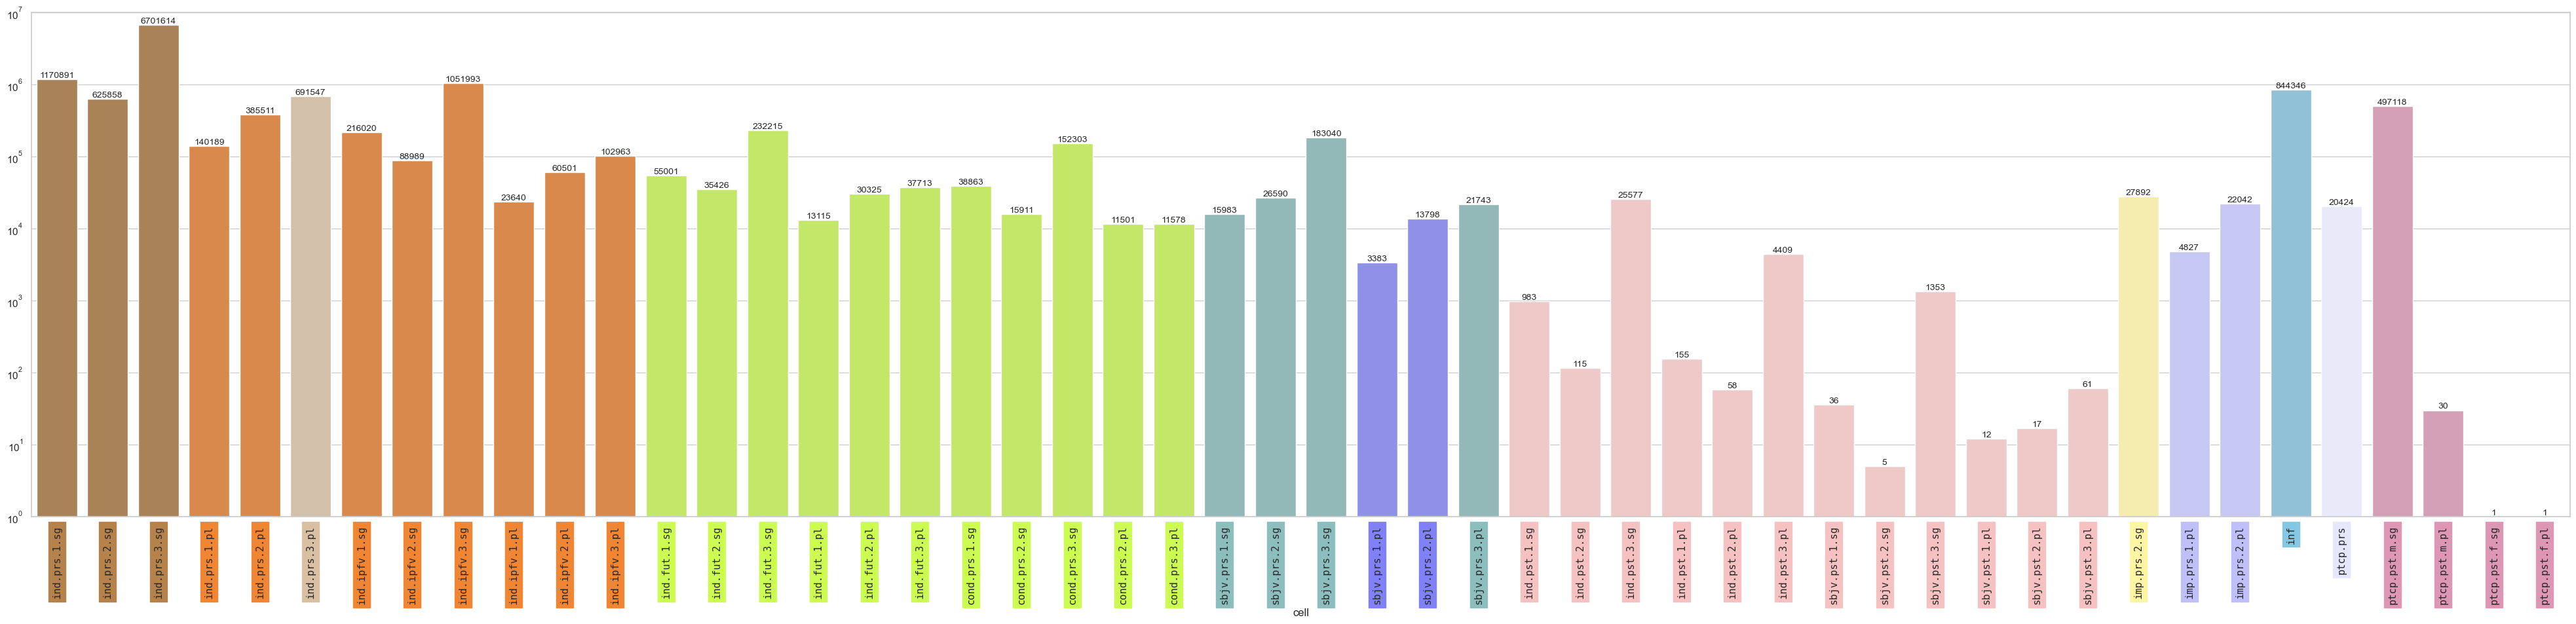

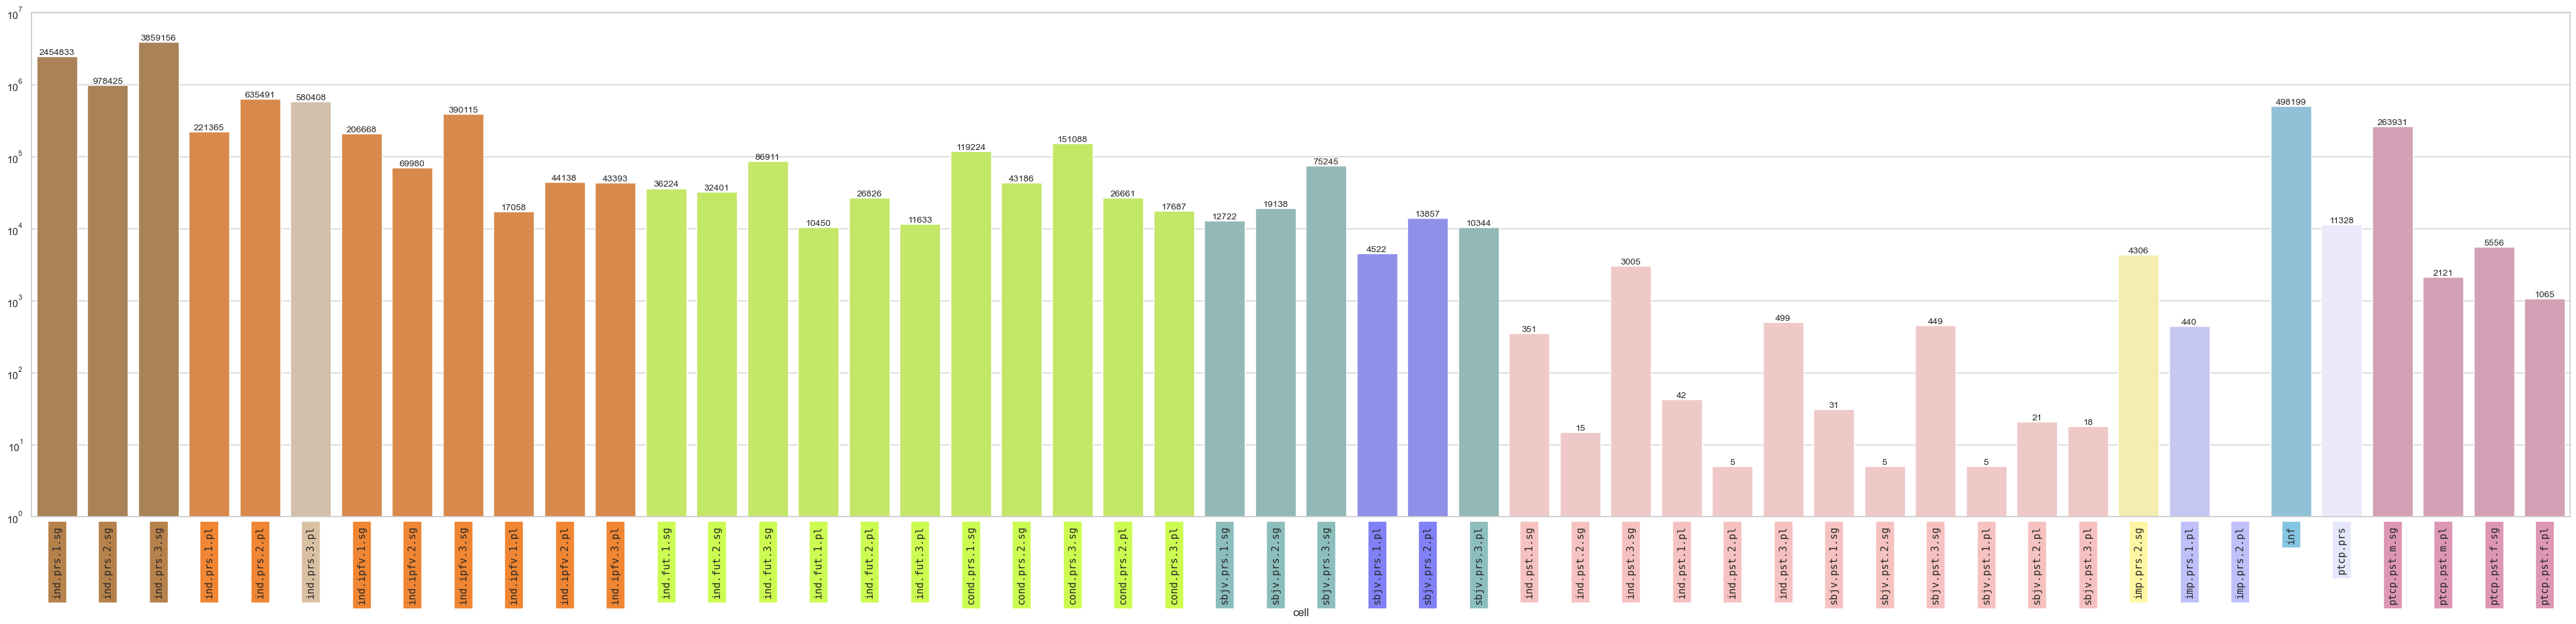

In [74]:
lexs=["être","avoir"]
for lex in lexs:
    data=dfDistLex.loc[lex].T
    for cell in ordStem:
        if cell not in data.columns:
            data[cell]=0
    reStems=[sc for sc in ordStem if sc in data.columns]
    reColors=[pltFlexColors[stem] for stem in reStems]
    reColors
    plt.figure(figsize=(50,10))
    ax=sns.barplot(data=data[reStems],palette=reColors)
    ax.set_yscale("log")
    ax.set_ylim(1, 10000000)
    ax.tick_params(axis='x', labelrotation=90)
    for axC in ax.containers:
        ax.bar_label(axC, fontsize=10,fmt="%.0f")
    # ax.bar_label(ax.containers, fontsize=10)
    colorerXTicks(ax,fSize=12)
    
    # paletteSbjv=[pltFlexColors[stem] for stem in ["ind.ipfv.1.pl","sbjv.prs.1.pl","ind.ipfv.2.pl","sbjv.prs.2.pl"]]
    # plt.figure(figsize=(6,3))
    # ax=sns.barplot(data=data[["ind.ipfv.1.pl","sbjv.prs.1.pl","ind.ipfv.2.pl","sbjv.prs.2.pl"]],palette=paletteSbjv)
    # # ax.set_ylim(0, 100000)


In [75]:
import numpy as np
from numpy.linalg import norm

paire="être","avoir"
# define two lists or array
dfA = dfDistLex.loc[paire[0]].T
for cell in ordStem:
    if cell not in dfA.columns:
        dfA[cell]=0
A=dfA[ordStem].values
# display(A)

dfB = dfDistLex.loc[paire[1]].T
for cell in ordStem:
    if cell not in dfB.columns:
        dfB[cell]=0
B=dfB[ordStem].values
# display(B) 
 
# compute cosine similarity
cosine = np.dot(A,B.T)/(norm(A)*norm(B))
print("Similarité: %.1f"%(cosine[0][0]*100))

Similarité: 91.7


### Distance entre distributions normées

In [76]:
dfDistNorm=round(dfDistLex/dfDistLex.groupby(level=0).sum()*100,2)
dfDistNorm

frequency
lexeme   cell                    
abaisser cond.prs.1.sg       1.80
         cond.prs.2.pl       0.43
         cond.prs.2.sg       0.66
         cond.prs.3.pl       0.19
         cond.prs.3.sg       2.04
...                           ...
être     sbjv.pst.1.sg       0.00
         sbjv.pst.2.pl       0.00
         sbjv.pst.2.sg       0.00
         sbjv.pst.3.pl       0.00
         sbjv.pst.3.sg       0.01

[109080 rows x 1 columns]

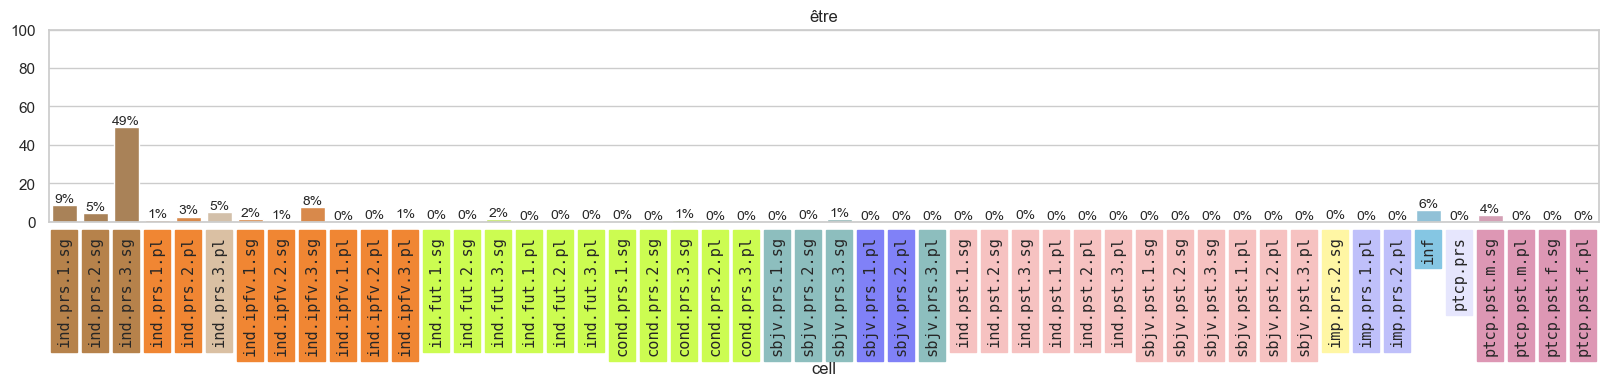

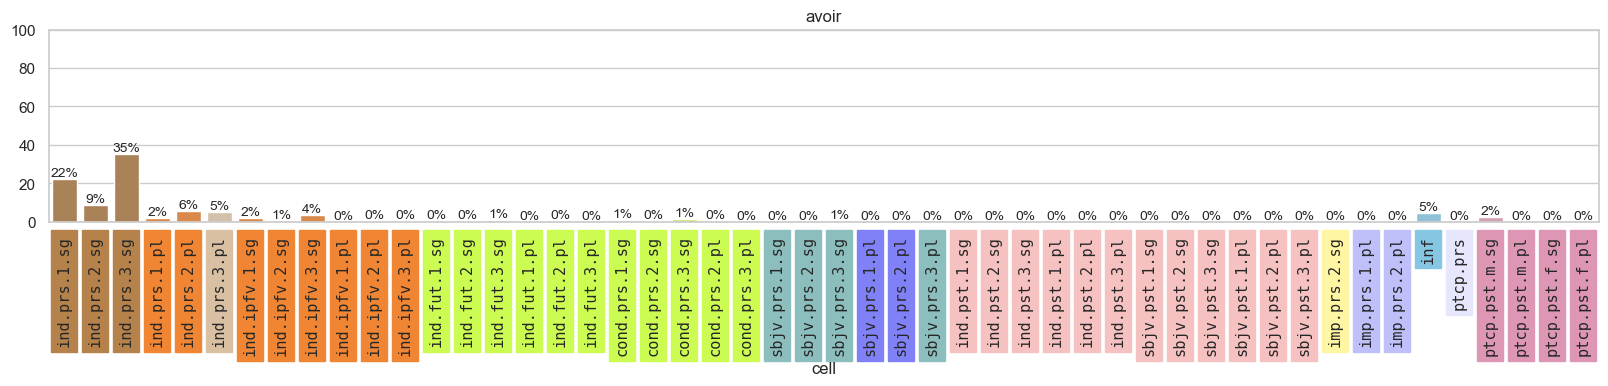

In [77]:
lexs=["être","avoir"]
for lex in lexs:
    data=dfDistNorm.loc[lex].T
    for cell in ordStem:
        if cell not in data.columns:
            data[cell]=0
    reStems=[sc for sc in ordStem if sc in data.columns]
    reColors=[pltFlexColors[stem] for stem in reStems]
    reColors
    plt.figure(figsize=(20,2.5))
    ax=sns.barplot(data=data[reStems],palette=reColors)
    ax.set_title(lex)
    ax.set_yscale("linear")
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', labelrotation=90)
    for axC in ax.containers:
        ax.bar_label(axC, fontsize=10,fmt="%.0f%%")
    # ax.bar_label(ax.containers, fontsize=10)
    colorerXTicks(ax,fSize=10)
    
    # paletteSbjv=[pltFlexColors[stem] for stem in ["ind.ipfv.1.pl","sbjv.prs.1.pl","ind.ipfv.2.pl","sbjv.prs.2.pl"]]
    # plt.figure(figsize=(6,3))
    # ax=sns.barplot(data=data[["ind.ipfv.1.pl","sbjv.prs.1.pl","ind.ipfv.2.pl","sbjv.prs.2.pl"]],palette=paletteSbjv)
    # # ax.set_ylim(0, 100000)


In [78]:
paire="être","avoir"
# define two lists or array
dfA = dfDistNorm.loc[paire[0]].T
for cell in ordStem:
    if cell not in dfA.columns:
        dfA[cell]=0
A=dfA[ordStem].values
# display(A)

dfB = dfDistLex.loc[paire[1]].T
for cell in ordStem:
    if cell not in dfB.columns:
        dfB[cell]=0
B=dfB[ordStem].values
# display(B) 
 
# compute cosine similarity
cosine = np.dot(A,B.T)/(norm(A)*norm(B))
print("Similarité: %.1f"%(cosine[0][0]*100))

Similarité: 91.7


In [23]:
%store

Stored variables and their in-db values:
conteLines                     -> {'040': ['1 040 le fiancé voleur', '2 il était une
dfHeterographes                -> '<unavailable>'
dfHeterographesBNC             -> '<unavailable>'
dfHomographes                  -> '<unavailable>'
dfHomographesBNC               -> '<unavailable>'
dfTripletsBNC                  -> '<unavailable>'
dfVerbsBNC                     -> '<unavailable>'
list_sentences_raw             -> [['welcome', 'to', 'somerset', 'so', 'easy', 'to',
list_sents_tok                 -> [['welcome', 'to', 'somerset', 'so', 'easy', 'to',
numerosKalaba                  -> [3]
ordStemCells                   -> ['pi1S', 'pi2S', 'pi3S', 'pi1P', 'pi2P', 'pi3P', '
overabundance                  -> {'be': [['are', 'be'], None, None], 'burn': [None,
pltCellColors                  -> {'ii1P': (0.9411764705882353, 0.5254901960784314, 
stats                          -> '<unavailable>'
typeKalaba                     -> 'Kalaba'


In [25]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, optimal_leaf_ordering

In [26]:
def getZ(dfLoc):
    dendX=dfLoc.values
    if norm:
        nNorm="norm"
        normX=[v/np.linalg.norm(v) for v in dendX]
        dendY=pdist(normX)
    else:
        nNorm="brut"
        dendY=pdist(dendX)
    dendZ=linkage(dendY)
    dendZ=optimal_leaf_ordering(dendZ,dendY)
    return dendZ

In [45]:
dfPar=pd.pivot_table(dfVlexique, values='frequency', index=['lexeme'], columns=['cell'], aggfunc="sum")[ordStem]
dfDend=dfDend.loc[dfPar.sum(axis=1)>=250]
dfDend

cell,ind.prs.1.sg,ind.prs.2.sg,ind.prs.3.sg,ind.prs.1.pl,ind.prs.2.pl,ind.prs.3.pl,ind.ipfv.1.sg,ind.ipfv.2.sg,ind.ipfv.3.sg,ind.ipfv.1.pl,...,sbjv.pst.3.pl,imp.prs.2.sg,imp.prs.1.pl,imp.prs.2.pl,inf,ptcp.prs,ptcp.pst.m.sg,ptcp.pst.m.pl,ptcp.pst.f.sg,ptcp.pst.f.pl
lexeme,,,,,,,,,,,,,,,,,,,,,
abaisser,55,52,178,10,21,40,7,3,9,0,...,0,173,16,242,657,35,166,40,60,22
abandonner,1797,1243,2881,229,708,691,133,53,234,10,...,0,1470,122,1049,13882,438,12898,1659,4008,872
abasourdir,0,1,4,0,0,0,0,0,0,0,...,0,0,0,2,11,0,173,57,58,3
abattre,313,95,751,15,98,208,17,6,69,2,...,0,124,41,448,5208,121,5221,1033,747,125
abdiquer,15,7,30,1,9,1,1,0,1,0,...,0,10,1,4,132,3,64,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
éviscérer,3,3,11,0,0,2,2,0,6,0,...,0,2,0,0,91,8,82,17,24,4
éviter,1126,833,2320,83,334,428,208,125,297,12,...,0,1555,712,1359,25218,576,2619,118,327,76
évoluer,76,29,895,44,29,427,11,2,91,4,...,0,11,1,6,1438,71,1528,77,42,16


In [57]:
dfPar.loc[dfPar.mean(axis=1)>=500]

cell,ind.prs.1.sg,ind.prs.2.sg,ind.prs.3.sg,ind.prs.1.pl,ind.prs.2.pl,ind.prs.3.pl,ind.ipfv.1.sg,ind.ipfv.2.sg,ind.ipfv.3.sg,ind.ipfv.1.pl,...,sbjv.pst.3.pl,imp.prs.2.sg,imp.prs.1.pl,imp.prs.2.pl,inf,ptcp.prs,ptcp.pst.m.sg,ptcp.pst.m.pl,ptcp.pst.f.sg,ptcp.pst.f.pl
lexeme,,,,,,,,,,,,,,,,,,,,,
abandonner,1797,1243,2881,229,708,691,133,53,234,10,...,0,1470,122,1049,13882,438,12898,1659,4008,872
accepter,4857,1793,4342,746,2528,1239,335,143,516,22,...,0,1667,116,1708,19172,561,14529,455,1591,329
acheter,3053,1655,5070,222,1161,1584,478,132,974,17,...,0,2306,237,2089,42824,643,27501,1286,2758,853
adorer,30289,1874,9470,363,562,4361,2003,502,3211,54,...,0,60,10,21,4681,36,5079,136,591,61
agir,1004,1939,37423,381,932,1201,161,126,4827,17,...,1,754,202,573,15381,787,5183,12,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
écouter,5814,4013,5879,326,2602,1698,1334,584,1408,67,...,0,24844,843,15554,27601,1269,7141,291,967,107
écrire,4868,2260,6170,129,1370,923,868,342,1708,32,...,0,1729,88,1391,27485,609,36446,1007,3151,1069
épouser,877,640,1402,10,265,162,136,65,163,0,...,0,734,1,250,17011,441,6683,49,1554,22


In [28]:
norm=True
dendZ=getZ(dfDend)

In [29]:
dendX=dfDend.values
if norm:
    nNorm="norm"
    normX=[v/np.linalg.norm(v) for v in dendX]
    dendY=pdist(normX)
else:
    nNorm="brut"
    dendY=pdist(dendX)
dendZ=linkage(dendY)
dendZ=optimal_leaf_ordering(dendZ,dendY)

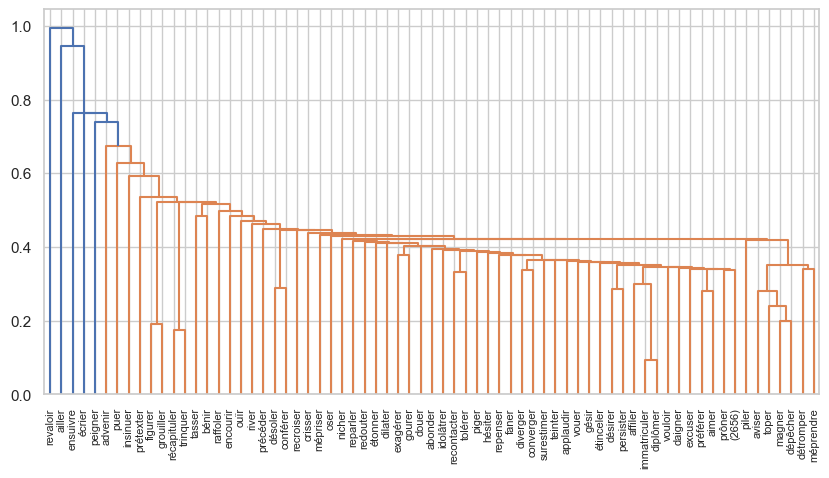

In [30]:
p0=50
plt.figure(figsize=(10,5)) #largeur, hauteur
# _=dendrogram(Z,truncate_mode="lastp")
R=dendrogram(dendZ,
             truncate_mode="level",
             leaf_font_size=8,
             p=p0,
             orientation="top",
             distance_sort=True,
             labels=dfDend.T.columns,leaf_rotation=90)
plt.savefig("DG-Vlexique-%s-p%d.pdf"%(nNorm,p0),bbox_inches='tight')

In [31]:
removeCluster=R["ivl"]
# removeCluster

In [32]:
dfSub1=dfDend.loc[~dfDend.index.isin(removeCluster)]
sub1Z=getZ(dfSub1)

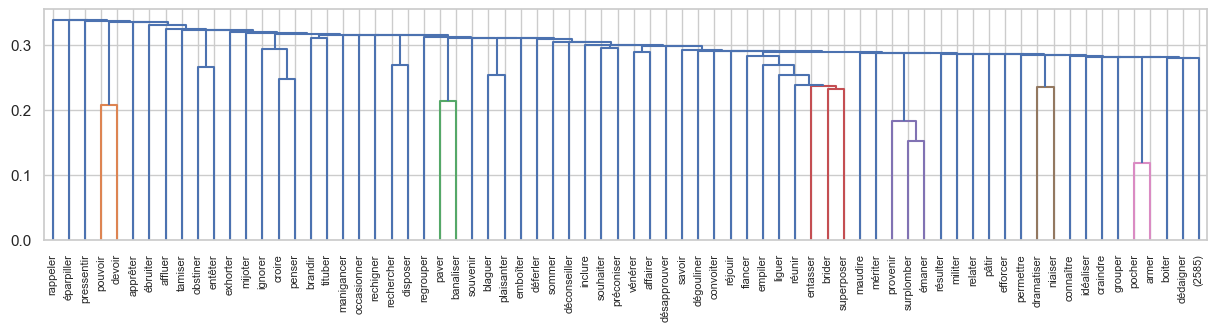

In [33]:
p1=50
plt.figure(figsize=(15,3))
# _=dendrogram(Z,truncate_mode="lastp")
R=dendrogram(sub1Z,
             truncate_mode="level",
             leaf_font_size=8,
             p=p1,
             orientation="top",
             distance_sort=True,
             labels=dfSub1.T.columns,leaf_rotation=90)
plt.savefig("DG-Vlexique-%s-p%d.%d.pdf"%(nNorm,p0,p1),bbox_inches='tight')

In [34]:
removeCluster+=R["ivl"]
# removeCluster

In [35]:
dfSub2=dfSub1.loc[~dfSub1.index.isin(removeCluster)]
sub2Z=getZ(dfSub2)

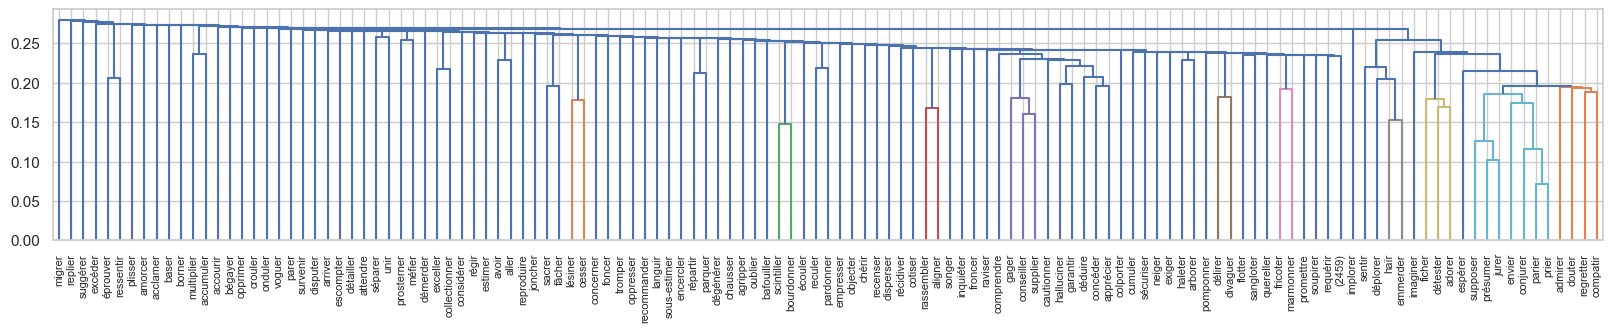

In [36]:
p2=80
plt.figure(figsize=(20,3))
# _=dendrogram(Z,truncate_mode="lastp")
R=dendrogram(sub2Z,
             truncate_mode="level",
             leaf_font_size=8,
             p=p2,
             orientation="top",
             distance_sort=True,
             labels=dfSub2.T.columns,leaf_rotation=90)
plt.savefig("DG-Vlexique-%s-p%d.%d.%d.pdf"%(nNorm,p0,p1,p2),bbox_inches='tight')

In [37]:
removeCluster+=R["ivl"]
# removeCluster

In [39]:
dfSub3=dfSub2.loc[~dfSub2.index.isin(removeCluster)]
sub3Z=getZ(dfSub3)

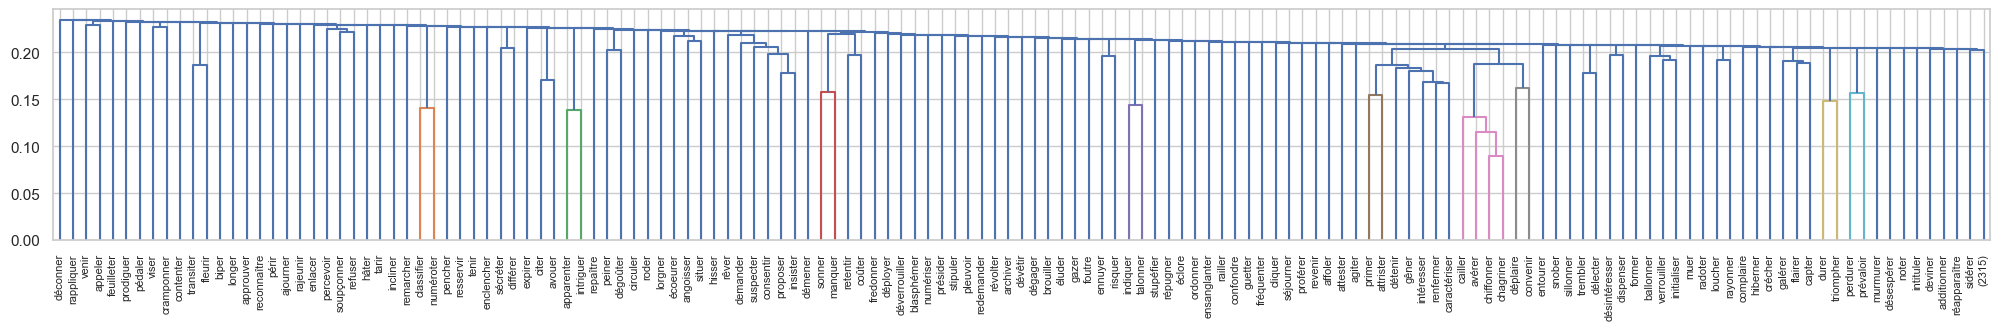

In [40]:
p3=100
plt.figure(figsize=(25,3))
# _=dendrogram(Z,truncate_mode="lastp")
R=dendrogram(sub3Z,
             truncate_mode="level",
             leaf_font_size=8,
             p=p3,
             orientation="top",
             distance_sort=True,
             labels=dfSub3.T.columns,leaf_rotation=90)
plt.savefig("DG-Vlexique-%s-p%d.%d.%d.%d.pdf"%(nNorm,p0,p1,p2,p3),bbox_inches='tight')

In [41]:
removeCluster+=R["ivl"]
# removeCluster

In [42]:
dfSub4=dfSub3.loc[~dfSub3.index.isin(removeCluster)]
sub4Z=getZ(dfSub4)

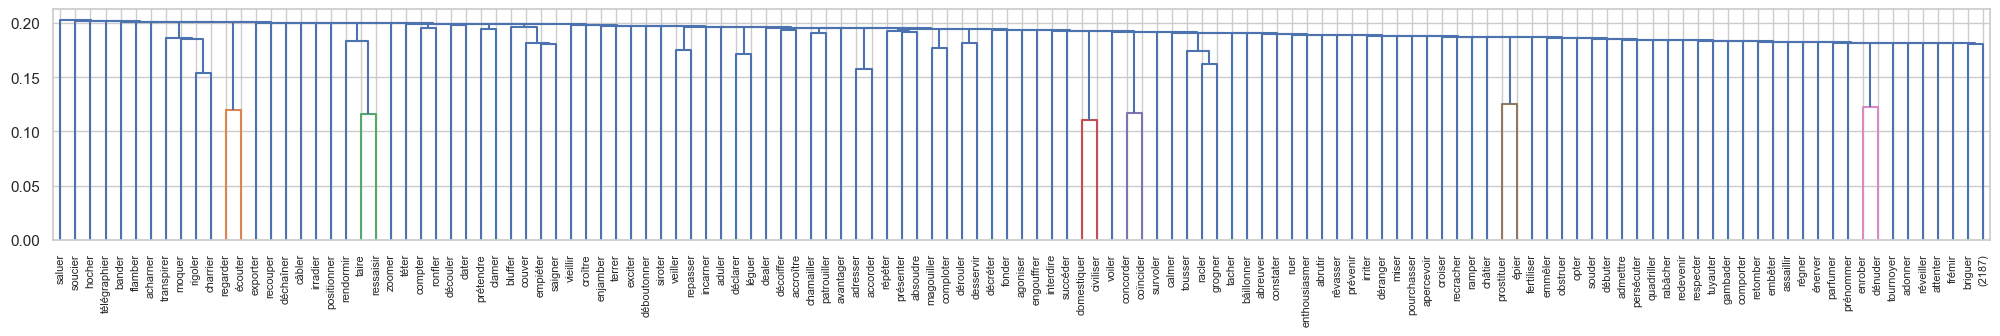

In [43]:
p4=100
plt.figure(figsize=(25,3))
# _=dendrogram(Z,truncate_mode="lastp")
R=dendrogram(sub4Z,
             truncate_mode="level",
             leaf_font_size=8,
             p=p4,
             orientation="top",
             distance_sort=True,
             labels=dfSub4.T.columns,leaf_rotation=90)
plt.savefig("DG-Vlexique-%s-p%d.%d.%d.%d.%d.pdf"%(nNorm,p0,p1,p2,p3,p4),bbox_inches='tight')